# Bonus Assignment
In this bonus assignment, you'll continue to use Pandas but with a specific scenario. You'll have to load a CSV dataset, explore it, and then clean it up to perform some visualizations and analysis. You'll also have to use the `matplotlib` library to create some visualizations.

The CSV is located at `https://raw.githubusercontent.com/paiml/wine-ratings/main/wine-ratings.csv`. Pandas has a seamless way to load CSVs from URLs, so you can use that to load the CSV. The example loading is provided for you in the first cell.


In [1]:
import pandas as pd 

csv_url = "https://raw.githubusercontent.com/paiml/wine-ratings/main/wine-ratings.csv"
df = pd.read_csv(csv_url)

## Explore the dataset
Explore the rows and columns of this wine dataset that has information about wines from all around the world with their ratings, regions, and variety. Spot any columns and rows that have invalid or missing values. 

Hint: There is one column with completely invalid data. Remove it from the dataset.

In [2]:
# Remove invalid columns
df.drop(["grape"], axis=1, inplace=True)
df

,Unnamed: 0,name,region,variety,rating,notes
0,0,1000 Stories Bourbon Barrel Aged Batch Blue Ca...,"Mendocino, California",Red Wine,91.0,"This is a very special, limited release of 100..."
1,1,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,89.0,The California Gold Rush was a period of coura...
2,2,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,90.0,The California Gold Rush was a period of coura...
3,3,1000 Stories Bourbon Barrel Aged Zinfandel 2013,"North Coast, California",Red Wine,91.0,"The wine has a deep, rich purple color. An int..."
4,4,1000 Stories Bourbon Barrel Aged Zinfandel 2014,California,Red Wine,90.0,Batch #004 is the first release of the 2014 vi...
...,...,...,...,...,...,...
32775,32775,Lewis Cellars Syrah Ethan's Blend 2005,California,Red Wine,92.0,"Now 7 years old, Alec's younger brother Ethan ..."
32776,32776,Lewis Cellars Syrah Ethan's Blend 2014,California,Red Wine,93.0,"Born in 2000, everything about Ethan and his n..."
32777,32777,Lewis Cellars Syrah Ethan's Blend 2009,California,Red Wine,94.0,"Positioned between brothers, Alec and Mason, E..."
32778,32778,Lexington Apex Red 2011,"Santa Cruz Mountains, California",Red Wine,91.0,"Blend: 99% Cabernet Sauvignon, 1% Merlot"


## Transform columns
Assume that "good wine" is anything about 94 points and above. Create a new column called `is_good_wine` that has a boolean value of `True` if the wine is good and `False` if it is not.

In [3]:
# Add column for is_good_wine
def check_good_wine(rating):
    if rating >= 94:
        return True
    return False

df["is_good_wine"] = df["rating"].apply(check_good_wine)
df

,Unnamed: 0,name,region,variety,rating,notes,is_good_wine
0,0,1000 Stories Bourbon Barrel Aged Batch Blue Ca...,"Mendocino, California",Red Wine,91.0,"This is a very special, limited release of 100...",False
1,1,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,89.0,The California Gold Rush was a period of coura...,False
2,2,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,Red Wine,90.0,The California Gold Rush was a period of coura...,False
3,3,1000 Stories Bourbon Barrel Aged Zinfandel 2013,"North Coast, California",Red Wine,91.0,"The wine has a deep, rich purple color. An int...",False
4,4,1000 Stories Bourbon Barrel Aged Zinfandel 2014,California,Red Wine,90.0,Batch #004 is the first release of the 2014 vi...,False
...,...,...,...,...,...,...,...
32775,32775,Lewis Cellars Syrah Ethan's Blend 2005,California,Red Wine,92.0,"Now 7 years old, Alec's younger brother Ethan ...",False
32776,32776,Lewis Cellars Syrah Ethan's Blend 2014,California,Red Wine,93.0,"Born in 2000, everything about Ethan and his n...",False
32777,32777,Lewis Cellars Syrah Ethan's Blend 2009,California,Red Wine,94.0,"Positioned between brothers, Alec and Mason, E...",True
32778,32778,Lexington Apex Red 2011,"Santa Cruz Mountains, California",Red Wine,91.0,"Blend: 99% Cabernet Sauvignon, 1% Merlot",False


## Create a visualization
Use the newly created columns to identify good vs. bad wines and create a visualization that shows the distribution of good vs. bad wines.

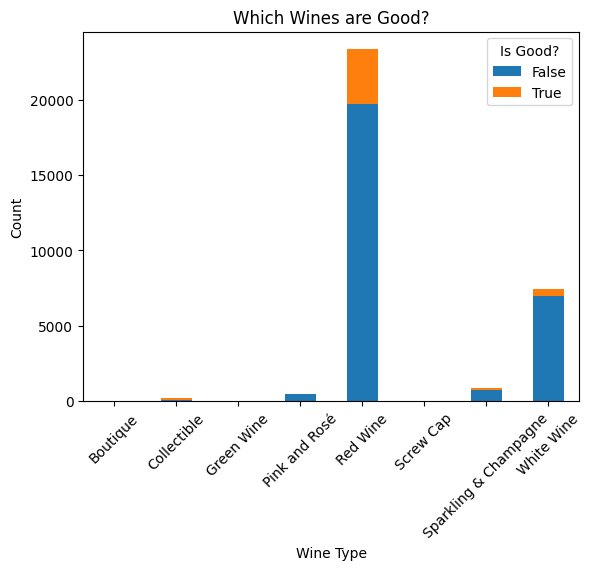

In [4]:
# Create visualization
import matplotlib.pyplot as plt

# Count the occurrences of each wine type and whether it is good or not
count_df = df.groupby(['variety', 'is_good_wine']).size().unstack() 
# The above calculates the size of each group and pivots the values in each into columns for easier readability.

# Plotting
count_df.plot(kind='bar', stacked=True) # Stacks the different is_good_wine counts on one bar.

plt.xlabel('Wine Type')
plt.ylabel('Count')

plt.title('Which Wines are Good?')
plt.legend(title='Is Good?')
plt.xticks(rotation=45) # Rotates labels so that they don't collide with each other

# Show plot
plt.show()

## Transform variety column
The variety column has different types of wine including red, white, and sparkling. Reduce the dataset to include only red and white wines, and add two new columns: one for `is_red` and one for `is_white`. The `is_red` column should have a boolean value of `True` if the wine is red and `False` if it is not. The `is_white` column should have a boolean value of `True` if the wine is white and `False` if it is not. 

Finally, drop the `variety` column.

In [5]:
# Create new columns for variety and drop variety column
df.query("variety == 'Red Wine' | variety == 'White Wine'", inplace=True)

df["is_red"] = df["variety"].apply(lambda x : x == 'Red Wine')
df["is_white"] = df["variety"].apply(lambda x : x == 'White Wine')

df.drop(["variety"], axis=1, inplace=True)
df

,Unnamed: 0,name,region,rating,notes,is_good_wine,is_red,is_white
0,0,1000 Stories Bourbon Barrel Aged Batch Blue Ca...,"Mendocino, California",91.0,"This is a very special, limited release of 100...",False,True,False
1,1,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,89.0,The California Gold Rush was a period of coura...,False,True,False
2,2,1000 Stories Bourbon Barrel Aged Gold Rush Red...,California,90.0,The California Gold Rush was a period of coura...,False,True,False
3,3,1000 Stories Bourbon Barrel Aged Zinfandel 2013,"North Coast, California",91.0,"The wine has a deep, rich purple color. An int...",False,True,False
4,4,1000 Stories Bourbon Barrel Aged Zinfandel 2014,California,90.0,Batch #004 is the first release of the 2014 vi...,False,True,False
...,...,...,...,...,...,...,...,...
32775,32775,Lewis Cellars Syrah Ethan's Blend 2005,California,92.0,"Now 7 years old, Alec's younger brother Ethan ...",False,True,False
32776,32776,Lewis Cellars Syrah Ethan's Blend 2014,California,93.0,"Born in 2000, everything about Ethan and his n...",False,True,False
32777,32777,Lewis Cellars Syrah Ethan's Blend 2009,California,94.0,"Positioned between brothers, Alec and Mason, E...",True,True,False
32778,32778,Lexington Apex Red 2011,"Santa Cruz Mountains, California",91.0,"Blend: 99% Cabernet Sauvignon, 1% Merlot",False,True,False
